<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Rattachement maillage géographique IRIS</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Construction des enrichissements géographiques IRIS et préparation des variables territoriales du pipeline immobilier.</p>
</div>

In [1]:
# Imports standards et scientifiques utilisés par le pipeline IRIS.
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Réglages d'affichage pour lire plus facilement les contrôles.
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Racine du projet : chemin local canonique, avec repli si le notebook est exécuté depuis un autre environnement.
PROJECT_ROOT = Path(r"C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
EXTERNAL_DIR = DATA_DIR / "external"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

for path in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Entrée canonique issue du notebook 03_definition_variables_bien.
INPUT_PATH = PROCESSED_DIR / "df_biens_residentiels_variables.parquet"

# Référentiel géographique externe.
IRIS_PATH = EXTERNAL_DIR / "insee" / "iris" / "iris-2013-01-01.shp"

# Sorties canoniques du notebook.
OUTPUT_PATH = PROCESSED_DIR / "df_biens_residentiels_iris.parquet"
IRIS_AGG_OUTPUT_PATH = PROCESSED_DIR / "df_iris_indicateurs_agreges.parquet"
IRIS_FINAL_OUTPUT_PATH = PROCESSED_DIR / "df_iris_geometries_indicateurs.parquet"
QA_OUTPUT_PATH = REPORTS_DIR / "qa_rattachement_iris.csv"
COLUMN_DICTIONARY_PATH = REPORTS_DIR / "04_dictionnaire_colonnes_iris.csv"
MANIFEST_PATH = REPORTS_DIR / "04_manifest_iris.json"

CONFIG = {
    "iris_file": IRIS_PATH,
    "crs_transactions": "EPSG:4326",
    "min_transactions_for_indicator": 1,
    "max_rate_no_match_warning": 0.05,
}

STANDARD_COLUMNS = {
    "id_mutation": "Identifiant unique de mutation DVF",
    "date_mutation": "Date de mutation",
    "code_commune": "Code commune INSEE sur 5 caractères",
    "code_departement": "Code departement sur 2 ou 3 caractères",
    "nom_commune": "Nom de la commune",
    "longitude": "Longitude WGS84",
    "latitude": "Latitude WGS84",
}

REQUIRED_TX_COLUMNS = ["longitude", "latitude", "date_mutation"]
REQUIRED_IRIS_COLUMNS = ["code_iris", "code_commune", "geometry"]

print("PROJECT_ROOT :", PROJECT_ROOT)
print("Entrée transactions :", INPUT_PATH)
print("Fichier IRIS attendu :", CONFIG["iris_file"])
print("Sortie principale :", OUTPUT_PATH)

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Fichier d'entrée introuvable : {INPUT_PATH}")

if not IRIS_PATH.exists():
    raise FileNotFoundError(f"Référentiel IRIS introuvable : {IRIS_PATH}")

PROJECT_ROOT : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Entrée transactions : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables.parquet
Fichier IRIS attendu : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\external\insee\iris\iris-2013-01-01.shp
Sortie principale : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_iris.parquet


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">FONCTIONS UTILITAIRES</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces fonctions font le travail de fond : contrôle des colonnes obligatoires, normalisation des codes administratifs, standardisation des transactions, standardisation du référentiel IRIS et sauvegarde des figures. Elles évitent de répéter la même logique dans plusieurs cellules.</div>
</div>

In [3]:
def require_columns(df: pd.DataFrame, required: list[str], df_name: str) -> None:
    """Arrête le pipeline si des colonnes obligatoires sont absentes."""
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"{df_name} — colonnes obligatoires absentes : {missing}")


def normalize_code_series(series: pd.Series, width: int | None = None) -> pd.Series:
    """Normalise une colonne de codes administratifs : string, strip, suppression du .0 éventuel, padding optionnel."""
    out = series.astype("string").str.strip()
    out = out.str.replace(r"\.0$", "", regex=True)
    out = out.mask(out.isin(["", "<NA>", "nan", "None"]))
    if width is not None:
        out = out.str.zfill(width)
    return out


def add_department_from_commune(df: pd.DataFrame) -> pd.DataFrame:
    """Crée code_departement a partir de code_commune si nécessaire."""
    if "code_departement" not in df.columns:
        df["code_departement"] = df["code_commune"].astype("string").str[:2]
        # Cas DOM : les codes communes commencent par 97x ou 98x ; le departement utile est sur 3 caractères.
        mask_dom = df["code_commune"].astype("string").str.startswith(("97", "98"), na=False)
        df.loc[mask_dom, "code_departement"] = df.loc[mask_dom, "code_commune"].astype("string").str[:3]
    return df


def standardize_transaction_schéma(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise le schéma transactionnel du pipeline DVF déjà nettoye."""
    df = df.copy()

    # Schema d'entrée explicite attendu pour ce notebook (pas de logique de devinette).
    required_tx_schéma = [
        "id_mutation",
        "date_mutation",
        "code_commune",
        "longitude",
        "latitude",
        "prix_m2",
        "surface_reference",
        "valeur_fonciere",
    ]
    require_columns(df, required_tx_schéma, "Transactions")

    df["code_commune"] = normalize_code_series(df["code_commune"], width=5)
    df = add_department_from_commune(df)
    df["code_departement"] = normalize_code_series(df["code_departement"])

    df["date_mutation"] = pd.to_datetime(df["date_mutation"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")

    return df


def standardize_iris_schéma(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Standardise le référentiel IRIS vers un formalisme unique."""
    gdf = gdf.copy()

    # Priorité explicite: DCOMIRIS (code IRIS complet a 9 caractères) avant IRIS (code quartier souvent sur 4 caractères).
    if "DCOMIRIS" in gdf.columns:
        gdf["code_iris"] = gdf["DCOMIRIS"]
    elif "CODE_IRIS" in gdf.columns:
        gdf["code_iris"] = gdf["CODE_IRIS"]
    elif "CODEIRIS" in gdf.columns:
        gdf["code_iris"] = gdf["CODEIRIS"]
    elif "IRIS" in gdf.columns:
        gdf["code_iris"] = gdf["IRIS"]

    rename_map = {
        "NOM_IRIS": "nom_iris",
        "TYP_IRIS": "type_iris",
        "DEPCOM": "code_commune",
        "NOM_COM": "nom_commune",
    }
    effective_rename = {src: dst for src, dst in rename_map.items() if src in gdf.columns and src != dst}
    gdf = gdf.rename(columns=effective_rename)

    # En cas de collisions d'alias, on conserve la première occurrence de chaque colonne standard.
    gdf = gdf.loc[:, ~gdf.columns.duplicated()].copy()

    require_columns(gdf, REQUIRED_IRIS_COLUMNS, "Referentiel IRIS")

    gdf["code_iris"] = normalize_code_series(gdf["code_iris"])
    gdf["code_commune"] = normalize_code_series(gdf["code_commune"], width=5)
    gdf = add_department_from_commune(gdf)
    gdf["code_departement"] = normalize_code_series(gdf["code_departement"])

    for col in ["nom_iris", "type_iris", "nom_commune"]:
        if col not in gdf.columns:
            gdf[col] = pd.NA

    keep_cols = [
        "code_iris", "nom_iris", "type_iris", "code_commune", "code_departement", "nom_commune", "geometry"
    ]
    return gdf[keep_cols].copy()


def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CHARGEMENT DES TRANSACTIONS</h3>
  <div style="color: #4b5563; font-size: 14px;">La première source disponible est chargée. Le schéma transactionnel est contrôlé et normalisé. Les premières lignes sont affichées pour vérifier la structure avant la jointure spatiale.</div>
</div>

In [4]:
# Chargement de la source transactionnelle canonique, puis passage au schéma fixe.
selected_input = INPUT_PATH
raw_tx = pd.read_parquet(INPUT_PATH)

df_tx = standardize_transaction_schéma(raw_tx)

print("Source transactionnelle utilisée :", selected_input)
print(f"Shape transactions : {df_tx.shape[0]:,} lignes | {df_tx.shape[1]:,} colonnes")
print("Colonnes standard disponibles :", [c for c in STANDARD_COLUMNS if c in df_tx.columns])
display(df_tx.head())

Source transactionnelle utilisée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_variables.parquet
Shape transactions : 3,925,350 lignes | 86 colonnes
Colonnes standard disponibles : ['id_mutation', 'date_mutation', 'code_commune', 'code_departement', 'nom_commune', 'longitude', 'latitude']


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,nb_lignes,nb_locaux,nb_appartements,nb_maisons,nb_dependances,surface_bati_totale,surface_terrain_totale,nb_pieces_total,nombre_lots_total,surface_carrez_totale,has_bati,has_terrain,has_imm_special,nb_seg_terrain_a_batir,nb_seg_agricole,nb_seg_agrement,nb_seg_bois_landes,nb_seg_sols,nb_seg_autre,nb_logements,has_logement,has_dependance,mutation_simple_logement,mutation_multiple_logements,ratio_bati_terrain_mutation,type_marche_mutation,type_mutation_economique,avec_dependances,categorie_logement,sous_categorie_logement,type_bien,surface_reference,source_surface_reference,surface_terrain_reference,prix_m2,prix_par_piece,ratio_bati_terrain,flag_valeur_valide,flag_surface_reference_valide,flag_prix_m2_valide,flag_qualite_globale,flag_residentiel,flag_surface_non_positive,flag_valeur_non_positive,flag_prix_m2_non_positif,flag_outlier_valeur_fonciere,flag_outlier_surface_reference,flag_outlier_prix_m2,flag_outlier,prix_m2_recalcule,flag_ecart_prix_m2_10pct,annee_mutation,log_prix_m2,prix_m2_winsor_01_99,log_valeur_fonciere,log_surface_reference,surface_reference_winsor,classe_surface,pieces_info_disponible,surface_par_piece,type_bien_residentiel,is_appartement,is_maison,segment_residentiel_surface,surface_terrain,surface_dependances,terrain_info_disponible,dependance_info_disponible,dependance_surface_info_disponible,ratio_terrain_bati,ratio_dependances_surface,intensite_batie,mois_mutation,trimestre_mutation,annee_mois_mutation,mois_depuis_debut
0,2021-1,2021-01-05,1,Vente,185000.0,01426,Val-Revermont,1,5.386107,46.327101,2,2,0,1,1,97.0,4820.0,5.0,0,NaN,True,1.0,False,0,0,0,0,2,0,1,True,1.0,True,False,0.020124,marche_secondaire_residentiel,maison,True,Maison,Maison moyenne (80-120 m²),Maison,97.00,bati,4820.0,1907.216495,37000.000000,0.020124,True,True,True,True,True,False,False,False,False,False,False,False,1907.216495,False,2021,7.553400,1907.216495,12.128111,4.574711,97.00,80-100,1,19.400000,maison,0,1,maison_standard,4820.0,NaN,1,1,0,49.690722,NaN,0.020124,1,1,2021-01,0
1,2021-10,2021-01-08,1,Vente,185000.0,01289,Péronnas,1,5.210182,46.187705,1,1,0,1,0,100.0,703.0,4.0,0,NaN,True,1.0,False,0,0,0,0,1,0,1,True,0.0,True,False,0.142248,marche_secondaire_residentiel,maison,False,Maison,Maison moyenne (80-120 m²),Maison,100.00,bati,703.0,1850.000000,46250.000000,0.142248,True,True,True,True,True,False,False,False,False,False,False,False,1850.000000,False,2021,7.522941,1850.000000,12.128111,4.605170,100.00,80-100,1,25.000000,maison,0,1,maison_standard,703.0,NaN,1,1,0,7.030000,NaN,0.142248,1,1,2021-01,0
2,2021-1000,2021-04-01,1,Vente,72150.0,01053,Bourg-en-Bresse,1,5.228652,46.213258,2,2,1,0,1,86.0,NaN,4.0,4,174.48,True,NaN,False,0,0,0,0,0,2,1,True,1.0,True,False,NaN,marche_secondaire_residentiel,appartement,True,Appartement,Appartement T4,Appartement,174.48,carrez,NaN,413.514443,18037.500000,NaN,True,True,True,True,True,False,False,False,False,False,False,False,413.514443,False,2021,6.024692,413.514443,11.186503,5.161810,174.48,150-250,1,43.620000,appartement,1,0,appartement_grand,NaN,NaN,0,1,0,NaN,NaN,NaN,4,2,2021-04,3
3,2021-10000,2021-03-03,1,Vente,51500.0,01185,Plateau d'Hauteville,1,5.610899,45.949372,3,1,0,1,0,70.0,483.0,3.0,0,NaN,True,1.0,False,0,0,0,1,2,0,1,True,0.0,True,False,0.144928,marche_secondaire_residentiel,maison,False,Maison,Petite maison (<=80 m²),Maison,70.00,bati,483.0,735.714286,17166.666667,0.144928,True,True,True,True,True,False,False,False,False,False,False,False,735.714286,False,2021,6.600842,735.714286,10.849337,4.248495,70.00,60-80,1,23.333333,maison,0,1,maison_petite,483.0,NaN,1,1,0,6.900000,NaN,0.144928,3,1,2021-03,2
4,2021-1000001,2021-12-10,1,Vente,45000.0,59122,Cambrai,59,3.230504,50.173132,1,1,0,1,0,70.0,65.0,5.0,0,NaN,True,1.0,False,0,0,0,0,1,0,1,True,0.0,True,False,1.076923,marche_secondaire_residentiel,maison,False,Maison,Petite maison (<=80 m²),Maison,70.00,bat

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">RÉFÉRENTIEL IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Le fond IRIS est ramené à un schéma simple : code IRIS, nom IRIS, type IRIS, commune, département et géométrie. Cette étape est importante, car le shapefile peut exposer des noms de colonnes différents selon les millésimes.</div>
</div>

In [5]:
# Chargement du référentiel IRIS brut, puis passage au schéma standard du notebook.
iris_file = CONFIG["iris_file"]
if not iris_file.exists():
    raise FileNotFoundError(f"Référentiel IRIS introuvable : {iris_file}")

iris_raw = gpd.read_file(iris_file)
iris = standardize_iris_schéma(iris_raw)

print("Fichier IRIS utilisé :", iris_file)
print("Shape IRIS brut :", iris_raw.shape)
print("Shape IRIS standardisé :", iris.shape)
print("CRS IRIS :", iris.crs)
print("Colonnes IRIS standardisées :", iris.columns.tolist())
display(iris.head())

Fichier IRIS utilisé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\external\insee\iris\iris-2013-01-01.shp
Shape IRIS brut : (508980, 8)
Shape IRIS standardisé : (508980, 7)
CRS IRIS : EPSG:4326
Colonnes IRIS standardisées : ['code_iris', 'nom_iris', 'type_iris', 'code_commune', 'code_departement', 'nom_commune', 'geometry']


,code_iris,nom_iris,type_iris,code_commune,code_departement,nom_commune,geometry
0,972010000,L'AJOUPA-BOUILLON,Z,97201,972,L' AJOUPA-BOUILLON,"POLYGON ((-61.09797 14.83121, -61.09867 14.830..."
1,972020000,LES ANSES-D'ARLET,Z,97202,972,LES ANSES-D'ARLET,"POLYGON ((-61.07379 14.54041, -61.07337 14.538..."
2,972030000,BASSE-POINTE,Z,97203,972,BASSE-POINTE,"POLYGON ((-61.08307 14.85248, -61.08441 14.850..."
3,972040000,LE CARBET,Z,97204,972,LE CARBET,"POLYGON ((-61.15649 14.73308, -61.15488 14.733..."
4,972050000,CASE-PILOTE,Z,97205,972,CASE-PILOTE,"POLYGON ((-61.12423 14.69021, -61.12086 14.689..."


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CONTRÔLE DU MAILLAGE IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Chaque IRIS doit apparaître une seule fois. En cas de géométries multiples pour un même code IRIS, elles sont regroupées afin de garder une clé territoriale unique.</div>
</div>

In [ ]:
# Vérification de l'unicité des codes IRIS.
# Un code IRIS doit correspondre à une seule entité géographique.

dup_iris = iris.duplicated("code_iris").sum()
print("Doublons code_iris avant correction :", dup_iris)

if dup_iris > 0:
    iris_doublons = iris.loc[
        iris.duplicated("code_iris", keep=False),
        ["code_iris", "nom_iris", "type_iris", "code_commune", "nom_commune", "geometry"]
    ].sort_values("code_iris")

    display(iris_doublons.drop(columns="geometry").head(20))

    # Séparation des lignes uniques et des lignes dupliquées.
    iris_uniques = iris.loc[~iris.duplicated("code_iris", keep=False)].copy()
    iris_a_fusionner = iris.loc[iris.duplicated("code_iris", keep=False)].copy()

    # Fusion uniquement des géométries concernées par les doublons.
    iris_fusionnes = (
        iris_a_fusionner
        .dissolve(
            by="code_iris",
            aggfunc={
                "nom_iris": "first",
                "type_iris": "first",
                "code_commune": "first",
                "code_departement": "first",
                "nom_commune": "first",
            }
        )
        .reset_index()
    )

    # Reconstruction du GeoDataFrame final.
    iris = pd.concat([iris_uniques, iris_fusionnes], ignore_index=True)
    iris = gpd.GeoDataFrame(iris, geometry="geometry", crs=iris_uniques.crs)

# Contrôles après correction.
assert iris["code_iris"].notna().all(), "Des IRIS n'ont pas de code_iris."
assert iris.duplicated("code_iris").sum() == 0, "Des doublons code_iris subsistent."

print("Shape IRIS final :", iris.shape)
print("Codes IRIS uniques :", iris["code_iris"].nunique())

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">PRÉPARATION GÉOGRAPHIQUE DES TRANSACTIONS</h3>
  <div style="color: #4b5563; font-size: 14px;">Les coordonnées manquantes sont comptées. Les coordonnées hors bornes géographiques sont retirées. Les transactions restantes sont converties en points géographiques.</div>
</div>

In [ ]:
# Préparation des transactions géolocalisables avant jointure spatiale.
n_initial = len(df_tx)
coord_missing = df_tx[["longitude", "latitude"]].isna().any(axis=1).sum()
coord_invalid = (
    df_tx["longitude"].notna()
    & df_tx["latitude"].notna()
    & ~(df_tx["longitude"].between(-180, 180) & df_tx["latitude"].between(-90, 90))
).sum()

df_geo = df_tx.dropna(subset=["longitude", "latitude"]).copy()
df_geo = df_geo[df_geo["longitude"].between(-180, 180) & df_geo["latitude"].between(-90, 90)].copy()
df_geo = df_geo.reset_index(drop=True)
df_geo["id_tx_tmp"] = df_geo.index

gdf_tx = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo["longitude"], df_geo["latitude"]),
    crs=CONFIG["crs_transactions"],
)

print("Transactions initiales :", n_initial)
print("Transactions sans coordonnées :", int(coord_missing))
print("Coordonnées invalides :", int(coord_invalid))
print("Transactions géolocalisables :", len(gdf_tx))
display(df_tx[["longitude", "latitude"]].describe())

Transactions initiales : 3925350
Transactions sans coordonnées : 39547
Coordonnées invalides : 0
Transactions géolocalisables : 3885803


,longitude,latitude
count,3.885803e+06,3.885803e+06
mean,2.507476e+00,4.611848e+01
std,6.727095e+00,6.349213e+00
min,-6.314278e+01,-2.138556e+01
25%,6.765405e-01,4.439664e+01
50%,2.419339e+00,4.707837e+01
75%,4.785042e+00,4.882955e+01
max,5.582912e+01,8.351771e+01


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">RATTACHEMENT SPATIAL TRANSACTION → IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">La jointure spatiale affecte chaque transaction à l'IRIS qui contient son point géographique. Les colonnes territoriales finales viennent du référentiel IRIS, afin d'éviter les conflits entre la source DVF et le fond géographique.</div>
</div>

In [ ]:
# Jointure spatiale transaction -> IRIS avec colonnes territoriales finales explicites.
# Préparation explicite du référentiel de jointure (attributs IRIS prefixes pour eviter tout conflit).
iris_join = iris[["code_iris", "nom_iris", "type_iris", "code_commune", "code_departement", "nom_commune", "geometry"]].rename(
    columns={
        "code_commune": "code_commune_iris",
        "code_departement": "code_departement_iris",
        "nom_commune": "nom_commune_iris",
    }
)

if iris_join.crs != gdf_tx.crs:
    iris_join = iris_join.to_crs(gdf_tx.crs)

gdf_tx_iris = gpd.sjoin(
    gdf_tx,
    iris_join,
    how="left",
    predicate="within",
)

# Colonnes territoriales finales : elles viennent exclusivement du référentiel IRIS.
gdf_tx_iris["code_commune_tx"] = gdf_tx_iris["code_commune"]
gdf_tx_iris["code_departement_tx"] = gdf_tx_iris["code_departement"]
gdf_tx_iris["code_commune"] = gdf_tx_iris["code_commune_iris"]
gdf_tx_iris["code_departement"] = gdf_tx_iris["code_departement_iris"]
gdf_tx_iris["nom_commune"] = gdf_tx_iris["nom_commune_iris"]

gdf_tx_iris["iris_match_status"] = np.where(gdf_tx_iris["code_iris"].isna(), "no_match", "within")

print("Lignes apres jointure :", len(gdf_tx_iris))
print("Transactions uniques apres jointure :", gdf_tx_iris["id_tx_tmp"].nunique())
print("Colonnes territoriales standard :", ["code_iris", "code_commune", "code_departement", "nom_iris", "type_iris", "nom_commune"])

Lignes apres jointure : 3885803
Transactions uniques apres jointure : 3885803
Colonnes territoriales standard : ['code_iris', 'code_commune', 'code_departement', 'nom_iris', 'type_iris', 'nom_commune']


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CONTROLE QUALITÉ DU RATTACHEMENT</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette section mesure le taux de transactions rattachées et non rattachées. Un taux élevé de non-rattachement signale un problème de coordonnées, de projection ou de couverture du référentiel IRIS.</div>
</div>

In [ ]:
# Tableau de qualite du rattachement spatial (volume, matchs, no-match).
n_after_join = len(gdf_tx_iris)
n_no_match = int(gdf_tx_iris["code_iris"].isna().sum())
n_with_match = n_after_join - n_no_match
rate_no_match = n_no_match / n_after_join if n_after_join else np.nan

qa_rattachement = pd.DataFrame([
    {"indicateur": "transactions_entrée", "valeur": int(n_initial)},
    {"indicateur": "transactions_sans_coordonnees", "valeur": int(coord_missing)},
    {"indicateur": "transactions_coordonnees_invalides", "valeur": int(coord_invalid)},
    {"indicateur": "transactions_geolocalisables", "valeur": int(len(gdf_tx))},
    {"indicateur": "transactions_apres_jointure", "valeur": int(n_after_join)},
    {"indicateur": "transactions_avec_iris", "valeur": int(n_with_match)},
    {"indicateur": "transactions_sans_iris", "valeur": int(n_no_match)},
    {"indicateur": "taux_sans_iris", "valeur": round(float(rate_no_match), 6)},
])

display(qa_rattachement)
print("IRIS observés :", gdf_tx_iris["code_iris"].nunique(dropna=True))

if pd.notna(rate_no_match) and rate_no_match > CONFIG["max_rate_no_match_warning"]:
    print(f"WARNING — taux de non-rattachement élevé : {rate_no_match:.2%}")

,indicateur,valeur
0,transactions_entrée,3.925350e+06
1,transactions_sans_coordonnees,3.954700e+04
2,transactions_coordonnees_invalides,0.000000e+00
3,transactions_geolocalisables,3.885803e+06
4,transactions_apres_jointure,3.885803e+06
5,transactions_avec_iris,3.881817e+06
6,transactions_sans_iris,3.986000e+03
7,taux_sans_iris,1.026000e-03


IRIS observés : 47790


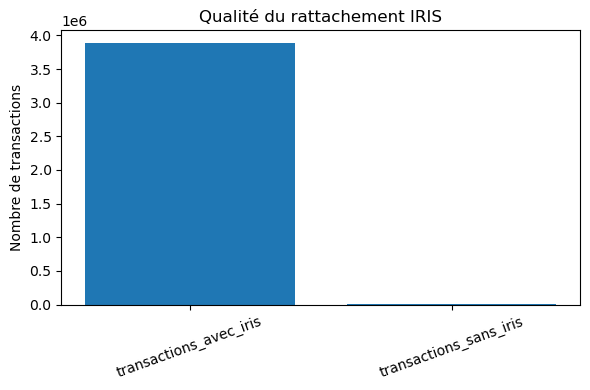

Figure exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_qualite_rattachement_iris.png


In [ ]:
# Visualisation simple du nombre de transactions avec et sans IRIS.
qa_plot = qa_rattachement[qa_rattachement["indicateur"].isin(["transactions_avec_iris", "transactions_sans_iris"])]

plt.figure(figsize=(6, 4))
plt.bar(qa_plot["indicateur"], qa_plot["valeur"])
plt.title("Qualité du rattachement IRIS")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=20)
fig_path_qa = save_current_figure("00_04_qualite_rattachement_iris.png")
plt.show()

print("Figure exportée :", fig_path_qa)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Le rattachement spatial aux IRIS présente un excellent niveau de couverture : la quasi-totalité des transactions résidentielles est correctement associée à une zone IRIS, tandis que les cas non rattachés restent marginaux. Ce résultat confirme la bonne qualité des coordonnées géographiques ainsi que la cohérence des géométries utilisées pour la jointure spatiale. Les rares transactions sans correspondance peuvent provenir de coordonnées imprécises, de points situés hors des polygones disponibles ou de limites géographiques incomplètes sur certains territoires. Le taux résiduel d’échec demeure suffisamment faible pour garantir la robustesse des futurs enrichissements territoriaux et des analyses géospatiales du pipeline.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">AGRÉGATION AU NIVEAU IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Les transactions correctement rattachées sont agrégées par IRIS. Les indicateurs produits décrivent le volume local, le niveau de prix, la surface médiane et la valeur foncière médiane.</div>
</div>

In [ ]:
# Agrégation des transactions rattachées vers une table indicateurs au niveau IRIS.
tx_ok = gdf_tx_iris.dropna(subset=["code_iris"]).copy()

group_cols = ["code_iris", "nom_iris", "type_iris", "code_commune", "code_departement", "nom_commune"]
require_columns(
    tx_ok,
    ["code_iris", "id_tx_tmp", "prix_m2", "surface_reference", "valeur_fonciere"],
    "Transactions rattachees",
)

# Agrégation IRIS explicite (schéma fixe).
df_iris = (
    tx_ok.groupby(group_cols, dropna=False)
    .agg(
        nb_transactions=("id_tx_tmp", "nunique"),
        prix_m2_med=("prix_m2", "median"),
        prix_m2_moy=("prix_m2", "mean"),
        surface_med=("surface_reference", "median"),
        valeur_med=("valeur_fonciere", "median"),
    )
    .reset_index()
)

feature_candidates = ["nb_transactions", "prix_m2_med", "prix_m2_moy", "surface_med", "valeur_med"]

print("Shape base IRIS agregee :", df_iris.shape)
display(df_iris.head())

Shape base IRIS agregee : (47790, 11)


,code_iris,nom_iris,type_iris,code_commune,code_departement,nom_commune,nb_transactions,prix_m2_med,prix_m2_moy,surface_med,valeur_med
0,010010000,L'ABERGEMENT-CLEMENCIAT,Z,01001,01,L'ABERGEMENT-CLEMENCIAT,32,2552.631579,2562.957715,95.00,252500.0
1,010020000,L'ABERGEMENT-DE-VAREY,Z,01002,01,L'ABERGEMENT-DE-VAREY,14,1826.071716,1754.514060,108.00,221450.0
2,010040101,LES PEROUSES-TRIANGLE D'ACTIVITE,H,01004,01,AMBERIEU-EN-BUGEY,93,2275.682705,2180.083188,90.00,205000.0
3,010040102,LONGERAY-GARE,H,01004,01,AMBERIEU-EN-BUGEY,243,1938.851603,1887.731321,85.37,145000.0
4,010040201,CENTRE-ST GERMAIN-VAREILLES,H,01004,01,AMBERIEU-EN-BUGEY,284,2018.100984,2031.864603,88.00,169500.0


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CONTRÔLES DES INDICATEURS</h3>
  <div style="color: #4b5563; font-size: 14px;">Les distributions sont inspectées. Les valeurs manquantes sont mesurées. La variabilité et les corrélations donnent une première lecture de la qualité analytique des variables.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Référentiel IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Le référentiel IRIS contient les polygones géographiques dans lesquels les transactions seront rattachées. La standardisation est indispensable, car les noms de colonnes peuvent varier selon les millésimes ou les sources.</div>
</div>

In [ ]:
# Contrôle statistique de base des indicateurs agreges (distribution, NA, variabilite).
print("Indicateurs disponibles :", feature_candidates)
display(df_iris[feature_candidates].describe().T)

missing_indicators = df_iris[feature_candidates].isna().mean().sort_values().to_frame("taux_na")
display(missing_indicators)

variabilite = pd.DataFrame({
    "nb_valeurs_distinctes": df_iris[feature_candidates].nunique(dropna=True),
    "ecart_type": df_iris[feature_candidates].std(numeric_only=True),
}).sort_values("nb_valeurs_distinctes")
display(variabilite)

Indicateurs disponibles : ['nb_transactions', 'prix_m2_med', 'prix_m2_moy', 'surface_med', 'valeur_med']


,count,mean,std,min,25%,50%,75%,max
nb_transactions,47790.0,81.226554,117.195580,1.000000,11.000000,34.000000,118.000000,7.353000e+03
prix_m2_med,47790.0,2080.017095,1405.309311,302.083333,1224.630160,1699.029126,2459.898705,3.538462e+04
prix_m2_moy,47790.0,2158.030181,1419.399043,302.083333,1305.950512,1755.476142,2518.949643,3.538462e+04
surface_med,47790.0,91.894274,21.835376,10.790000,80.000000,90.000000,101.000000,4.790000e+02
valeur_med,47790.0,178478.643779,108567.886494,20000.000000,112000.000000,155000.000000,217659.375000,3.650000e+06


,taux_na
nb_transactions,0.0
prix_m2_med,0.0
prix_m2_moy,0.0
surface_med,0.0
valeur_med,0.0


,nb_valeurs_distinctes,ecart_type
nb_transactions,750,117.195580
surface_med,5318,21.835376
valeur_med,12328,108567.886494
prix_m2_med,37645,1405.309311
prix_m2_moy,47688,1419.399043


,correlation_pearson
surface_med,-0.268969
nb_transactions,0.367297
valeur_med,0.817877
prix_m2_moy,0.983568


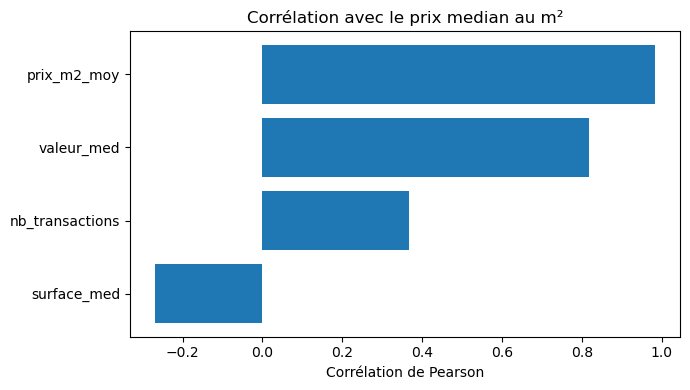

Figure exportee : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_correlation_prix_m2_med.png


In [ ]:
# Corrélation des indicateurs avec le prix median IRIS pour lecture rapide des dependances lineaires.
corr_candidates = [c for c in feature_candidates if c != "prix_m2_med"]
corr_target = (
    df_iris[corr_candidates + ["prix_m2_med"]]
    .corr(numeric_only=True)["prix_m2_med"]
    .drop("prix_m2_med")
    .sort_values()
)
display(corr_target.to_frame("correlation_pearson"))

plt.figure(figsize=(7, 4))
plt.barh(corr_target.index, corr_target.values)
plt.title("Corrélation avec le prix median au m²")
plt.xlabel("Corrélation de Pearson")
fig_path_corr = save_current_figure("00_04_correlation_prix_m2_med.png")
plt.show()
print("Figure exportee :", fig_path_corr)

,nb_transactions,prix_m2_med,prix_m2_moy,surface_med,valeur_med
nb_transactions,1.000000,0.367297,0.365035,0.328154,0.182273
prix_m2_med,0.367297,1.000000,0.983568,0.268969,0.817877
prix_m2_moy,0.365035,0.983568,1.000000,0.259491,0.828104
surface_med,0.328154,0.268969,0.259491,1.000000,0.156041
valeur_med,0.182273,0.817877,0.828104,0.156041,1.000000


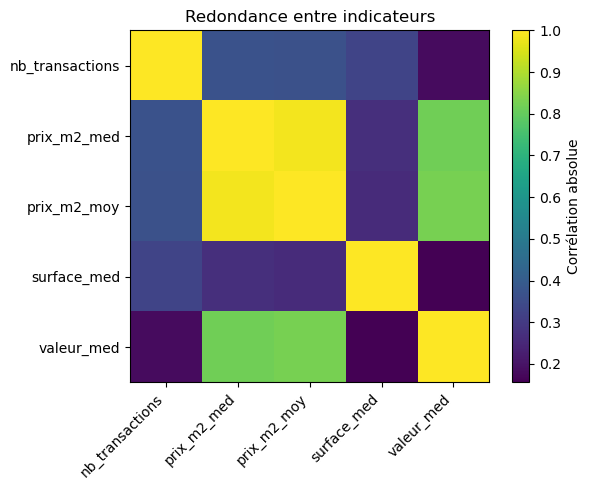

Figure exportee : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_redondance_indicateurs_iris.png


In [ ]:
# Matrice de redondance entre indicateurs agreges pour detecter les variables tres correlees.
corr_matrix = df_iris[feature_candidates].corr(numeric_only=True).abs()
display(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar(label="Corrélation absolue")
plt.title("Redondance entre indicateurs")
fig_path_redundancy = save_current_figure("00_04_redondance_indicateurs_iris.png")
plt.show()
print("Figure exportee :", fig_path_redundancy)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette matrice met en évidence plusieurs relations fortes entre les indicateurs agrégés au niveau territorial. Les prix médians et moyens au m² présentent une corrélation extrêmement élevée, ce qui indique qu’ils capturent une information économique très proche. Les territoires chers en médiane sont également chers en moyenne. La valeur foncière médiane est également fortement liée aux niveaux de prix au m². Cette relation est cohérente : les zones où les prix unitaires sont élevés concentrent mécaniquement des transactions de valeur plus importante. À l’inverse, la surface médiane apparaît beaucoup moins corrélée aux indicateurs de prix. Cela suggère que la taille des biens ne suffit pas à expliquer les écarts territoriaux de valorisation immobilière. Le volume de transactions présente des corrélations relativement modérées avec les autres variables. Les départements les plus actifs ne sont donc pas nécessairement les plus chers.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Malgré certaines corrélations élevées, il reste prématuré d’éliminer des variables à ce stade du pipeline. Une forte corrélation statistique ne traduit pas nécessairement une redondance métier complète. Certaines variables peuvent conserver un intérêt spécifique selon l’échelle géographique étudiée, les modèles utilisés, les interactions entre variables ou les besoins d’interprétabilité. La sélection finale des variables sera réalisée ultérieurement lors des phases de modélisation et d’évaluation prédictive.</div>
</div>

In [ ]:
# Tableau de décision métier sur les indicateurs produits au niveau IRIS.
decision_features = pd.DataFrame([
    {"variable": "nb_transactions", "statut": "conserver", "raison": "mesure la profondeur du marché local"},
    {"variable": "prix_m2_med", "statut": "cible / indicateur", "raison": "indicateur central, robuste aux valeurs extrêmes"},
    {"variable": "prix_m2_moy", "statut": "surveiller", "raison": "utile en lecture, mais souvent redondant avec la médiane"},
    {"variable": "surface_med", "statut": "conserver", "raison": "décrit la structure des biens échangés"},
    {"variable": "valeur_med", "statut": "surveiller", "raison": "porte une information de niveau de marché mais peut être corrélée au prix"},
    {"variable": "type_iris", "statut": "conserver", "raison": "variable catégorielle territoriale"},
])

decision_features = decision_features[decision_features["variable"].isin(feature_candidates + ["type_iris"])]
display(decision_features)

print("Top 10 IRIS par prix_m2_med")
display(df_iris.sort_values("prix_m2_med", ascending=False).head(10))

print("Bottom 10 IRIS par prix_m2_med")
display(df_iris.sort_values("prix_m2_med", ascending=True).head(10))

,variable,statut,raison
0,nb_transactions,conserver,mesure la profondeur du marché local
1,prix_m2_med,cible / indicateur,"indicateur central, robuste aux valeurs extrêmes"
2,prix_m2_moy,surveiller,"utile en lecture, mais souvent redondant avec ..."
3,surface_med,conserver,décrit la structure des biens échangés
4,valeur_med,surveiller,porte une information de niveau de marché mais...
5,type_iris,conserver,variable catégorielle territoriale


Top 10 IRIS par prix_m2_med


,code_iris,nom_iris,type_iris,code_commune,code_departement,nom_commune,nb_transactions,prix_m2_med,prix_m2_moy,surface_med,valeur_med
47056,955720117,VERT GALANT,A,95572,95,SAINT-OUEN-L'AUMONE,1,35384.615385,35384.615385,65.00,2300000.0
6084,141182001,MONT COCO,A,14118,14,CAEN,2,28347.062410,28347.062410,75.00,2142140.0
5410,130630110,PLATE FORME,A,13063,13,MIRAMAS,1,27279.267692,27279.267692,65.00,1773152.4
37030,751166199,SEINE ET BERGES,D,75116,75,PARIS 16E ARRONDISSEMENT,1,17549.354414,17549.354414,37.95,665998.0
8204,181740000,OSMOY,Z,18174,18,OSMOY,2,17178.530425,17178.530425,73.50,580000.0
33633,692590201,ZI VENISSIEUX CORBAS ST-PRIEST,A,69259,69,VENISSIEUX,1,16417.910448,16417.910448,67.00,1100000.0
36444,751010102,SAINT-GERMAIN L'AUXERROIS 2,A,75101,75,PARIS 1ER ARRONDISSEMENT,27,15633.423181,15476.053145,54.66,1010000.0
36501,751041603,NOTRE DAME 3,A,75104,75,PARIS 4E ARRONDISSEMENT,4,14929.366635,13358.175957,46.44,461425.0
36548,751062402,SAINT-GERMAIN DES PRES 2,H,75106,75,PARIS 6E ARRONDISSEMENT,297,14382.845188,14314.981842,55.02,720000.0
36457,751020502,GAILLON 2,A,75102,75,PARIS 2E ARRONDISSEMENT,41,13979.665940,13703.300833,55.92,725000.0


Bottom 10 IRIS par prix_m2_med


,code_iris,nom_iris,type_iris,code_commune,code_departement,nom_commune,nb_transactions,prix_m2_med,prix_m2_moy,surface_med,valeur_med
23404,500370000,LA BAZOGE,Z,50037,50,LA BAZOGE,1,302.083333,302.083333,96.0,29000.0
19390,394190000,PILLEMOINE,Z,39419,39,PILLEMOINE,1,302.816901,302.816901,142.0,43000.0
24885,521490000,COURCELLES-SUR-BLAISE,Z,52149,52,COURCELLES-SUR-BLAISE,3,303.030303,345.454545,70.0,21000.0
26332,551400000,CUNEL,Z,55140,55,CUNEL,1,304.878049,304.878049,82.0,25000.0
43588,883070000,MONT-LES-LAMARCHE,Z,88307,88,MONT-LES-LAMARCHE,1,310.679612,310.679612,103.0,32000.0
34421,704500000,LA ROCHELLE,Z,70450,70,LA ROCHELLE,1,313.492063,313.492063,126.0,39500.0
26034,544470000,RECLONVILLE,Z,54447,54,RECLONVILLE,1,315.151515,315.151515,165.0,52000.0
26452,552950000,LISLE-EN-BARROIS,Z,55295,55,LISLE-EN-BARROIS,1,315.789474,315.789474,95.0,30000.0
43481,881990000,GIGNEVILLE,Z,88199,88,GIGNEVILLE,2,316.666667,316.666667,100.0,31500.0
8467,191080000,LAROCHE-PRES-FEYT,Z,19108,19,LAROCHE-PRES-FEYT,2,322.916667,322.916667,115.0,37500.0


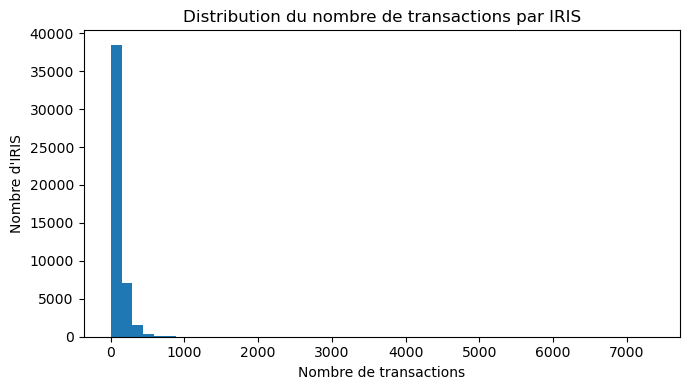

Figure exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_distribution_nb_transactions_iris.png


In [ ]:
# Distribution du volume de transactions par IRIS (controle de dispersion des tailles d'echantillon).
plt.figure(figsize=(7, 4))
plt.hist(df_iris["nb_transactions"], bins=50)
plt.title("Distribution du nombre de transactions par IRIS")
plt.xlabel("Nombre de transactions")
plt.ylabel("Nombre d'IRIS")
fig_path_volume = save_current_figure("00_04_distribution_nb_transactions_iris.png")
plt.show()
print("Figure exportée :", fig_path_volume)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">BASE IRIS FINALE</h3>
  <div style="color: #4b5563; font-size: 14px;">Le référentiel IRIS reste la table maître. Les indicateurs sont ajoutés par merge, ce qui permet de conserver les IRIS sans transaction avec un volume égal à zéro.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle du maillage IRIS</h3>
  <div style="color: #4b5563; font-size: 14px;">Avant la jointure spatiale, il est nécessaire de vérifier qu’un même code IRIS correspond à une seule entité géographique. Cette étape permet d’identifier les éventuels doublons, de consolider les géométries si nécessaire et de garantir la stabilité du référentiel territorial utilisé dans le pipeline analytique.</div>
</div>

In [ ]:
# Merge final explicite référentiel IRIS (maitre) + indicateurs agreges (detail).
iris_ref = iris[["code_iris", "nom_iris", "type_iris", "code_commune", "code_departement", "nom_commune", "geometry"]].copy()

# Merge final explicite sur code_iris : le référentiel IRIS reste la table maitre.
iris_indicators = df_iris[["code_iris", "nb_transactions", "prix_m2_med", "prix_m2_moy", "surface_med", "valeur_med"]].copy()

gdf_iris_final = iris_ref.merge(
    iris_indicators,
    on="code_iris",
    how="left",
)

gdf_iris_final["nb_transactions"] = gdf_iris_final["nb_transactions"].fillna(0).astype("int64")

print("Shape fichier final IRIS :", gdf_iris_final.shape)
print("IRIS sans transaction :", int((gdf_iris_final["nb_transactions"] == 0).sum()))
display(gdf_iris_final.head())

Shape fichier final IRIS : (50898, 12)
IRIS sans transaction : 3108


,code_iris,nom_iris,type_iris,code_commune,code_departement,nom_commune,geometry,nb_transactions,prix_m2_med,prix_m2_moy,surface_med,valeur_med
0,010010000,L'ABERGEMENT-CLEMENCIAT,Z,01001,01,L'ABERGEMENT-CLEMENCIAT,"POLYGON ((4.90308 46.15798, 4.90458 46.16096, ...",32,2552.631579,2562.957715,95.00,252500.0
1,010020000,L'ABERGEMENT-DE-VAREY,Z,01002,01,L'ABERGEMENT-DE-VAREY,"POLYGON ((5.43444 45.98435, 5.43009 45.98276, ...",14,1826.071716,1754.514060,108.00,221450.0
2,010040101,LES PEROUSES-TRIANGLE D'ACTIVITE,H,01004,01,AMBERIEU-EN-BUGEY,"POLYGON ((5.3278 45.95919, 5.32786 45.95935, 5...",93,2275.682705,2180.083188,90.00,205000.0
3,010040102,LONGERAY-GARE,H,01004,01,AMBERIEU-EN-BUGEY,"POLYGON ((5.34094 45.94907, 5.34062 45.94935, ...",243,1938.851603,1887.731321,85.37,145000.0
4,010040201,CENTRE-ST GERMAIN-VAREILLES,H,01004,01,AMBERIEU-EN-BUGEY,"POLYGON ((5.35787 45.9673, 5.35775 45.96689, 5...",284,2018.100984,2031.864603,88.00,169500.0


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">EXPORTS</h3>
  <div style="color: #4b5563; font-size: 14px;">Les sorties sont séparées par usage : transactions enrichies, agrégat IRIS, base finale, qualité de rattachement, dictionnaire de colonnes et manifest d'exécution.</div>
</div>

In [ ]:
# Exports finaux : transactions enrichies, agrégat IRIS, merge final, QA, dictionnaire et manifest.
# Les sorties sont écrites sur des chemins canoniques afin d'éviter les doublons et versions successives.
for path in [PROCESSED_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

out_tx_iris = OUTPUT_PATH
out_iris_agg = IRIS_AGG_OUTPUT_PATH
out_iris_final = IRIS_FINAL_OUTPUT_PATH
out_qa = QA_OUTPUT_PATH
out_dict = COLUMN_DICTIONARY_PATH
out_manifest = MANIFEST_PATH

# Nettoyage explicite des colonnes techniques de jointure avant export.
drop_cols_tx = ["index_right", "code_commune_iris", "code_departement_iris", "nom_commune_iris"]
gdf_tx_iris_export = gdf_tx_iris.drop(columns=drop_cols_tx, errors="ignore").copy()

gdf_tx_iris_export.to_parquet(out_tx_iris, index=False)
df_iris.to_parquet(out_iris_agg, index=False)
gdf_iris_final.to_parquet(out_iris_final, index=False)
qa_rattachement.to_csv(out_qa, index=False)

# Dictionnaire de colonnes : trace la presence des champs dans les sorties detail et finale.
column_dictionary = pd.DataFrame([
    {
        "colonne": col,
        "definition": STANDARD_COLUMNS.get(col, "Indicateur ou variable issue du pipeline"),
        "present_tx": col in gdf_tx_iris_export.columns,
        "present_iris_final": col in gdf_iris_final.columns,
    }
    for col in sorted(set(gdf_tx_iris_export.columns).union(set(gdf_iris_final.columns)))
])
column_dictionary.to_csv(out_dict, index=False)

# Manifest d'exécution pour audit et reproductibilite.
manifest = {
    "notebook": "04_rattachement_iris",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "input_transactions": str(selected_input),
    "input_iris": str(iris_file),
    "outputs": {
        "df_biens_residentiels_iris": str(out_tx_iris),
        "df_iris_indicateurs_agreges": str(out_iris_agg),
        "df_iris_geometries_indicateurs": str(out_iris_final),
        "qa_rattachement": str(out_qa),
        "dictionnaire_colonnes": str(out_dict),
    },
    "standard_keys": ["code_iris", "code_commune", "code_departement"],
    "figures": [str(p) for p in FIGURES_DIR.glob("04_*.png")],
    "qa": qa_rattachement.to_dict(orient="records"),
}

with open(out_manifest, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Export terminé :")
print("- Transactions avec IRIS :", out_tx_iris)
print("- Base IRIS agregee      :", out_iris_agg)
print("- Base IRIS finale       :", out_iris_final)
print("- QA rattachement        :", out_qa)
print("- Dictionnaire colonnes  :", out_dict)
print("- Manifest               :", out_manifest)
print("")
print("Shape transactions jointes :", gdf_tx_iris_export.shape)
print("Shape base IRIS agregee    :", df_iris.shape)
print("Shape base IRIS finale     :", gdf_iris_final.shape)

Export terminé :
- Transactions avec IRIS : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_iris.parquet
- Base IRIS agregee      : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_indicateurs_agreges.parquet
- Base IRIS finale       : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_geometries_indicateurs.parquet
- QA rattachement        : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\reports\qa_rattachement_iris.csv
- Dictionnaire colonnes  : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\reports\04_dictionnaire_colonnes_iris.csv
- Manifest               : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\reports\04_manifest_iris.json

Shape transactions jointes : (3885803, 94)
Shape base IRIS agregee    : (47790, 11)
Shape base IRIS finale     : (50

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">SYNTHÈSE</h3>
  <div style="color: #4b5563; font-size: 14px;">Le passage au niveau IRIS est opérationnel. Les clés territoriales sont standardisées. Les sorties produites peuvent alimenter les étapes d'enrichissement territorial, de modélisation et de cartographie. La principale limite reste la dépendance à la qualité des coordonnées DVF et à la couverture du référentiel IRIS utilisé. Les transactions sans coordonnées valides ne peuvent pas être rattachées spatialement.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CARTOGRAPHIES DÉPARTEMENTALES</h3>
  <div style="color: #4b5563; font-size: 14px;">Les cartes sont produites en deux temps. La France métropolitaine est traitée séparément des DROM pour éviter qu'une géométrie éloignée écrase l'emprise de la carte. Les DROM sont ensuite affichés en petits panneaux dédiés.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">FRANCE MÉTROPOLITAINE</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule garde explicitement les départements métropolitains, Corse comprise. Les autres territoires sont exclus par construction, ce qui évite les effets d'échelle observés avec une carte globale.</div>
</div>

Départements conservés pour la carte France :
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95']
Départements exclus du panneau France :
['971', '972', '973', '974', '977', '978']


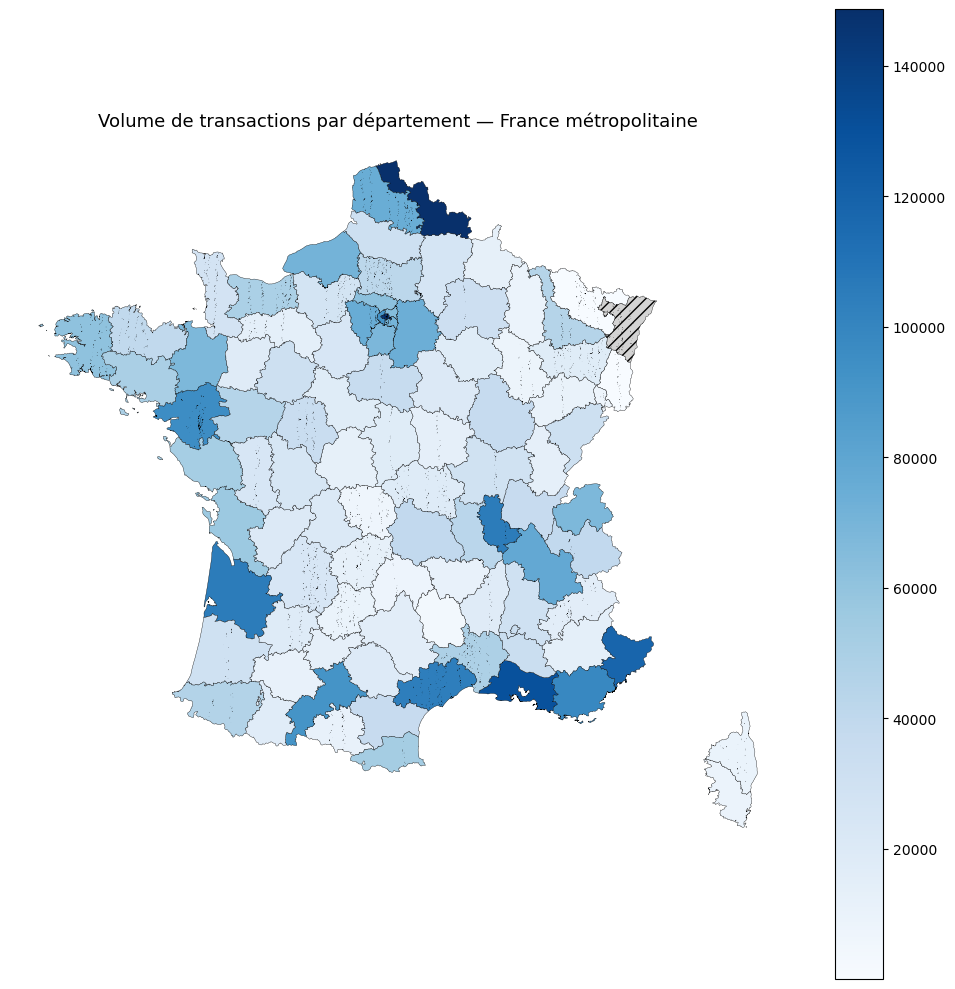

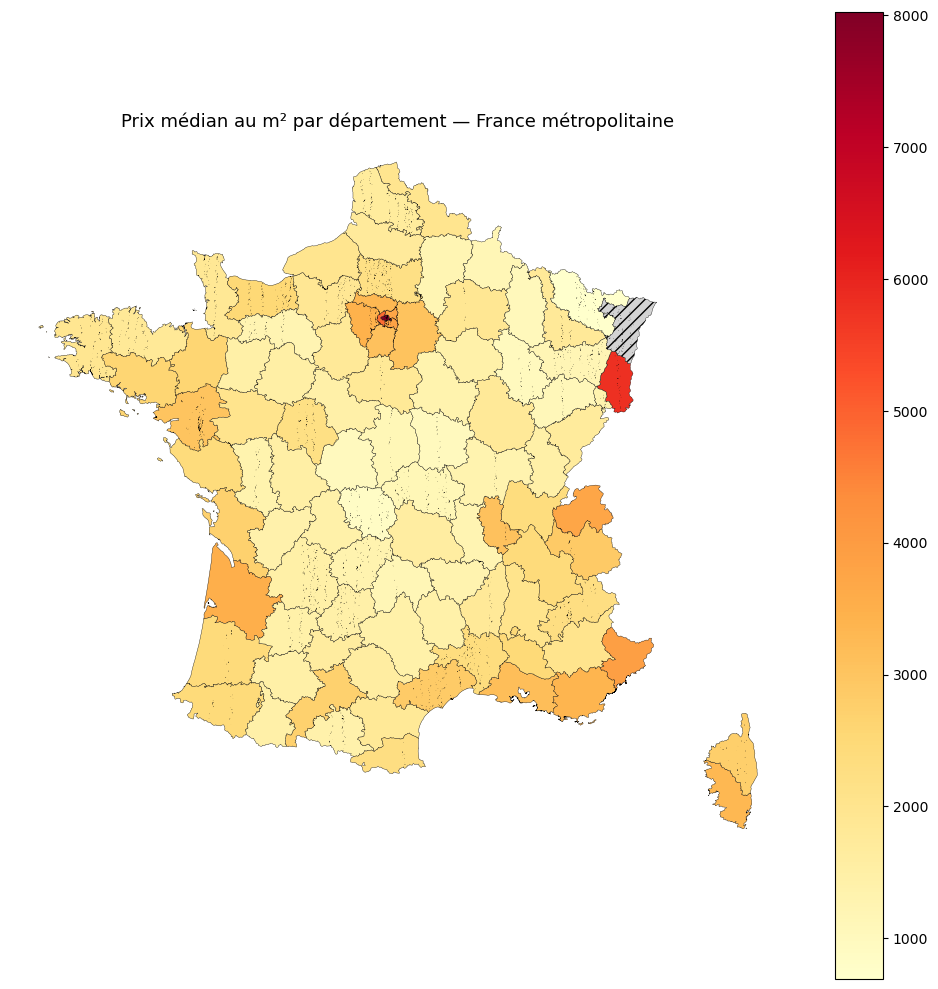

Source : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_iris.parquet
Carte volume France métropolitaine : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_cartographie_volume_transactions_france_metropolitaine.png
Carte prix France métropolitaine : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_cartographie_prix_m2_france_metropolitaine.png


In [ ]:
#  Cartographie de la France métropolitaine uniquement.
# On recharge les sources utiles pour que cette cellule puisse être relancée seule.
from pathlib import Path
import warnings

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

NOTEBOOK_TAG = "00_04"
PROJECT_ROOT = Path(r"C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sources transactionnelles possibles, dans l'ordre de préférence.
candidates = [
    PROCESSED_DIR / "df_biens_residentiels_iris.parquet",
    PROCESSED_DIR / "dvf_transactions_avec_iris.parquet",
]

source_path = next((p for p in candidates if p.exists()), None)
if source_path is None:
    raise FileNotFoundError("Aucun parquet trouvé pour la cartographie.")

# Lecture des transactions enrichies ou de la meilleure source disponible.
df_carto = pd.read_parquet(source_path)

if "code_departement" not in df_carto.columns:
    raise ValueError("La colonne code_departement est absente du jeu source.")


def normalize_code_departement(value):
    """Nettoie un code département sans transformer 2A/2B en nombre."""
    if pd.isna(value):
        return pd.NA
    value = str(value).strip().replace(".0", "")
    if value in {"", "nan", "None", "<NA>"}:
        return pd.NA
    if value.upper() in {"2A", "2B"}:
        return value.upper()
    if value.isdigit() and len(value) <= 2:
        return value.zfill(2)
    return value


def code_departement_from_commune(code_commune):
    """Déduit le département à partir d'un code commune ou d'un code IRIS."""
    code = normalize_code_departement(code_commune)
    if pd.isna(code):
        return pd.NA
    code = str(code)
    if code.startswith(("97", "98")):
        return code[:3]
    if code.startswith(("2A", "2B")):
        return code[:2]
    return code[:2]


def load_departements_from_iris(external_dir: Path) -> gpd.GeoDataFrame:
    """Reconstruit un fond départemental à partir du shapefile IRIS."""
    iris_path = external_dir / "insee" / "iris" / "iris-2013-01-01.shp"
    if not iris_path.exists():
        raise FileNotFoundError(f"Shapefile IRIS introuvable : {iris_path}")

    gdf_iris = gpd.read_file(iris_path)

    if "DCOMIRIS" in gdf_iris.columns:
        source_code = gdf_iris["DCOMIRIS"]
    elif "CODE_IRIS" in gdf_iris.columns:
        source_code = gdf_iris["CODE_IRIS"]
    elif "CODEIRIS" in gdf_iris.columns:
        source_code = gdf_iris["CODEIRIS"]
    elif "DEPCOM" in gdf_iris.columns:
        source_code = gdf_iris["DEPCOM"]
    else:
        raise ValueError("Impossible d'identifier un code IRIS ou commune dans le shapefile IRIS.")

    gdf_iris = gdf_iris.copy()
    gdf_iris["code_departement"] = source_code.apply(code_departement_from_commune)
    gdf_iris = gdf_iris.dropna(subset=["code_departement"])

    # Dissolve : une géométrie par département.
    gdf_dept = gdf_iris.dissolve(by="code_departement", aggfunc="first").reset_index()
    gdf_dept["code_departement"] = gdf_dept["code_departement"].apply(normalize_code_departement)
    return gdf_dept[["code_departement", "geometry"]].copy()


# Normalisation avant agrégation pour fiabiliser la jointure avec le fond géographique.
df_carto = df_carto.copy()
df_carto["code_departement"] = df_carto["code_departement"].apply(normalize_code_departement)

# Choix de la variable de prix disponible.
if "prix_m2" in df_carto.columns:
    price_col = "prix_m2"
elif "prix_m2_model" in df_carto.columns:
    price_col = "prix_m2_model"
else:
    price_col = None

agg_dict = {"n_transactions": ("code_departement", "size")}
if price_col is not None:
    agg_dict["prix_m2_median"] = (price_col, "median")

agg_dept = (
    df_carto
    .dropna(subset=["code_departement"])
    .groupby("code_departement", dropna=True)
    .agg(**agg_dict)
    .reset_index()
)
agg_dept["code_departement"] = agg_dept["code_departement"].apply(normalize_code_departement)

# Fond départemental reconstruit depuis les IRIS.
gdf_dept = load_departements_from_iris(EXTERNAL_DIR)

# Jointure fond géographique x indicateurs départementaux.
gdf_plot = gdf_dept.merge(agg_dept, on="code_departement", how="left")

# Liste stricte des départements métropolitains : 01 à 95 hors 20, plus Corse 2A/2B.
METRO_CODES = [f"{i:02d}" for i in range(1, 96) if i != 20] + ["2A", "2B"]

gdf_france = gdf_plot[gdf_plot["code_departement"].isin(METRO_CODES)].copy()

print("Départements conservés pour la carte France :")
print(sorted(gdf_france["code_departement"].dropna().unique()))
print("Départements exclus du panneau France :")
print(sorted(set(gdf_plot["code_departement"].dropna()) - set(gdf_france["code_departement"].dropna())))

# Lambert-93 : projection adaptée à la métropole.
try:
    gdf_france = gdf_france.to_crs(epsg=2154)
except Exception as e:
    print(f"Projection EPSG:2154 non appliquée : {e}")


def plot_france_metropolitaine(gdf, column, title, output_path, cmap):
    """Trace une carte départementale de la France métropolitaine."""
    if column not in gdf.columns:
        raise ValueError(f"Colonne absente du GeoDataFrame : {column}")

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.25,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans données",
        },
        ax=ax,
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")

    # Cadrage serré sur les départements conservés.
    minx, miny, maxx, maxy = gdf.total_bounds
    marge_x = (maxx - minx) * 0.04
    marge_y = (maxy - miny) * 0.04
    ax.set_xlim(minx - marge_x, maxx + marge_x)
    ax.set_ylim(miny - marge_y, maxy + marge_y)

    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


out_volume_france = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_volume_transactions_france_metropolitaine.png"

plot_france_metropolitaine(
    gdf_france,
    column="n_transactions",
    title="Volume de transactions par département — France métropolitaine",
    output_path=out_volume_france,
    cmap="Blues",
)

if "prix_m2_median" in gdf_france.columns:
    out_price_france = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_prix_m2_france_metropolitaine.png"

    plot_france_metropolitaine(
        gdf_france,
        column="prix_m2_median",
        title="Prix médian au m² par département — France métropolitaine",
        output_path=out_price_france,
        cmap="YlOrRd",
    )

print(f"Source : {source_path}")
print(f"Carte volume France métropolitaine : {out_volume_france}")

if "prix_m2_median" in gdf_france.columns:
    print(f"Carte prix France métropolitaine : {out_price_france}")
else:
    print("Carte prix France métropolitaine : non générée.")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">13.2 DROM</h3>
  <div style="color: #4b5563; font-size: 14px;">Les DROM sont représentés dans une figure séparée. Chaque territoire dispose de son propre panneau, avec une échelle de couleur commune à l'ensemble des DROM pour une lecture comparable.</div>
</div>

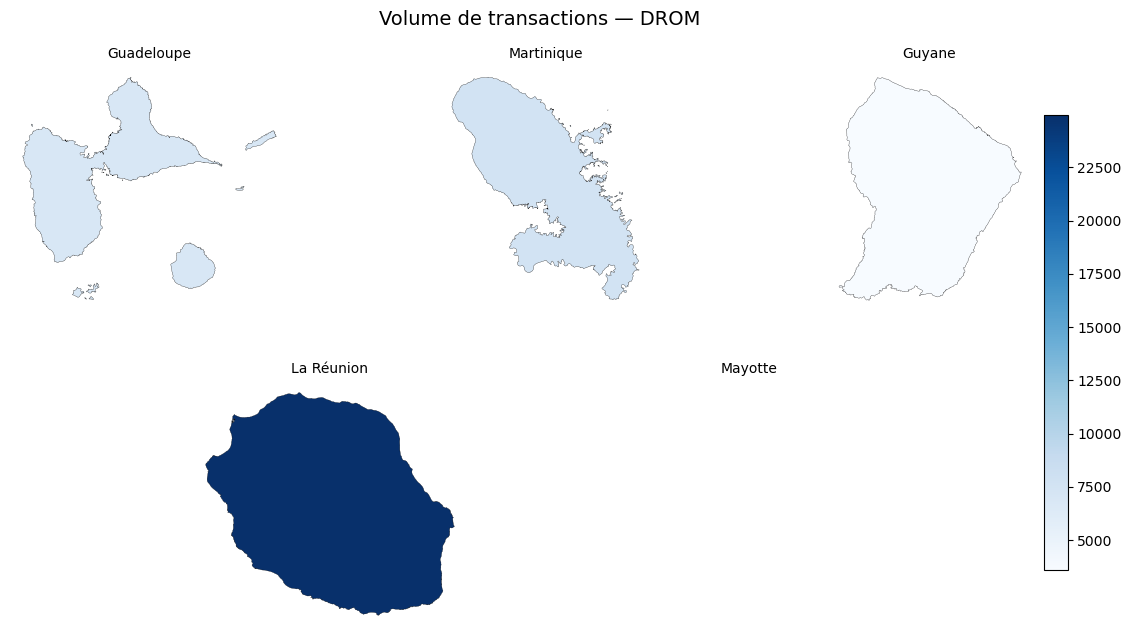

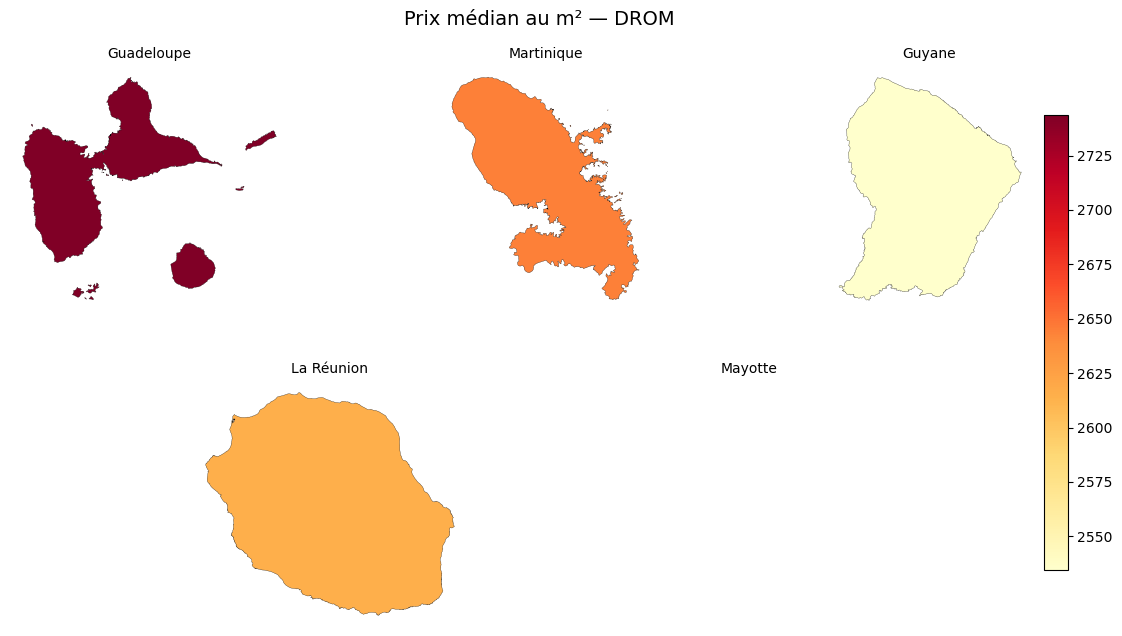

Carte volume DROM : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_cartographie_volume_transactions_drom.png
Carte prix DROM : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\00_04_cartographie_prix_m2_drom.png


In [ ]:
#  Cartographie des DROM uniquement.
# Cette cellule utilise gdf_plot construit dans la cellule France.

DROM_CODES = ["971", "972", "973", "974", "976"]

gdf_drom = gdf_plot[gdf_plot["code_departement"].isin(DROM_CODES)].copy()


def plot_drom(gdf, column, title, output_path, cmap):
    """Trace les DROM dans des panneaux séparés."""
    droms = {
        "Guadeloupe": "971",
        "Martinique": "972",
        "Guyane": "973",
        "La Réunion": "974",
        "Mayotte": "976",
    }

    if column not in gdf.columns:
        raise ValueError(f"Colonne absente du GeoDataFrame : {column}")

    vmin = gdf[column].min(skipna=True)
    vmax = gdf[column].max(skipna=True)

    fig = plt.figure(figsize=(12, 7))

    axes = {
        "Guadeloupe": fig.add_axes([0.05, 0.55, 0.25, 0.35]),
        "Martinique": fig.add_axes([0.38, 0.55, 0.25, 0.35]),
        "Guyane": fig.add_axes([0.70, 0.55, 0.25, 0.35]),
        "La Réunion": fig.add_axes([0.20, 0.10, 0.25, 0.35]),
        "Mayotte": fig.add_axes([0.55, 0.10, 0.25, 0.35]),
    }

    plot_kwargs = dict(
        column=column,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.2,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans données",
        },
    )

    for name, code in droms.items():
        ax = axes[name]
        subset = gdf[gdf["code_departement"] == code]

        if not subset.empty:
            subset.plot(ax=ax, **plot_kwargs)

        ax.set_title(name, fontsize=10)
        ax.axis("off")

    # Légende commune aux cinq panneaux.
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.65])
    fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


out_volume_drom = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_volume_transactions_drom.png"

plot_drom(
    gdf_drom,
    column="n_transactions",
    title="Volume de transactions — DROM",
    output_path=out_volume_drom,
    cmap="Blues",
)

if "prix_m2_median" in gdf_drom.columns:
    out_price_drom = FIG_DIR / f"{NOTEBOOK_TAG}_cartographie_prix_m2_drom.png"

    plot_drom(
        gdf_drom,
        column="prix_m2_median",
        title="Prix médian au m² — DROM",
        output_path=out_price_drom,
        cmap="YlOrRd",
    )

print(f"Carte volume DROM : {out_volume_drom}")

if "prix_m2_median" in gdf_drom.columns:
    print(f"Carte prix DROM : {out_price_drom}")
else:
    print("Carte prix DROM : non générée.")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce notebook produit un premier enrichissement territorial structurant pour le pipeline immobilier. Les mutations résidentielles sont désormais rattachées à une géographie IRIS exploitable pour les analyses spatiales, les segmentations territoriales et les futurs modèles prédictifs.</div>
</div>